# Constrained Cobb-Douglas with MPC: Theory and Hold-Out Results

The live intraday Cobb-Douglas (CD) engine that ran from 2026-05-05 to 2026-05-15 on a paper account was discontinued at market close on 2026-05-18 with a flat-with-bleed P&L. The diagnostic was clean: the allocator solved unconstrained CD at a 30-min clock, the turnover gate was disabled, and γ jitter at 30-min cadence was being rounded into ±1-share orders on 5-10 tickers per fire. The engine had no notion of cost, no notion of risk, no notion of holding, and fired on a clock with no information content.

This notebook walks through the design that replaces it: a **constrained Cobb-Douglas allocator** (covariance, turnover, and concentration budgets) wrapped in **model-predictive control (MPC)** discipline (forward-project, fire only when the realized path leaves a confidence band). The universe is a 33-ticker basket frozen from the S4 per-sector bandit (uniform 3-per-sector GICS quotas). We benchmark the design against five baselines on the 2025-2026 hold-out window with after-cost, after-tax accounting.

> **Learning Objectives:**
>
> * __Constrained allocation as a convex program:__ State the budget, covariance, turnover, and concentration constraints that wrap the Cobb-Douglas objective. Recognize that the resulting program is convex and solves in milliseconds at production basket sizes.
> * __Event-driven rebalancing:__ Define the MPC in-spec band and the three trigger conditions that decide when re-allocation fires. Explain why event-driven cadence replaces the live engine's information-free clock.
> * __Pairwise strategy comparison:__ Read the six-strategy bake-off and identify which row pairs isolate the cadence effect, the constraint effect, and the combined fix. Interpret a surprising or unexpected ranking against the design intent.

Let's walk through the theory and read the bake-off.


___
## Section 1: Theory

In this section, let's take a look at the constrained Cobb-Douglas formulation and the model predictive control (MPC) trigger conditions. We'll start by looking at a reformulated Cobb-Douglas allocation problem, then we'll examine the three trigger conditions that define the MPC discipline, and then wer'll end with a high-level algorithm that wraps the allocator in the MPC discipline.

### Constrained Cobb-Douglas Allocation with MPC Discipline
The idea behind the constrained Cobb-Douglas formulation is to wrap the classic Cobb-Douglas objective in constraints that are interpretable in client terms: a budget constraint, a covariance (risk) constraint, a turnover constraint, and a concentration constraint. The MPC discipline then defines when to fire the (re)allocator based on forward projections of the portfolio value.

> **Constrained Cobb-Douglas (CD) Optimization**
>
> Given a basket of $K$ tickers, share prices $\mathbf{p} \in \mathbb{R}^K_{>0}$, investment budget $B$, prior shares $\mathbf{n}_{\text{prev}} \in \mathbb{R}^K_{>0}$, single index model (SIM)-implied covariance $\boldsymbol{\Sigma}\in \mathbb{R}^{K \times K}$, and average transaction cost per share traded $\bar{c}\in \mathbb{R}_{>0}$ (commission + half-spread + slippage), solve this optimization problem for the number of new shares $\mathbf{n}_{\tau}$ at time $\tau$:
>
> $$\max_{n_i > 0} \; \sum_{i=1}^{K} \gamma_i \log(n_i)$$
>
> where the objective is the log of the Cobb-Douglas utility function. The optimization is subject to the constraints:
>
> $$\sum_i n_i p_i \le B, \quad \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \le \sigma_{\max}^2, \quad \bar{c}\,\|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}, \quad w_i \le w_{\max}, \quad n_i > 0$$
>
> where $w_i = n_i p_i / B$, $K_{\text{turnover}}$ denotes the turnover budget, and $\|\star\|_1$ is the L1 norm. Strict positivity ($n_i > 0$) is required for the log objective to be finite; the solver enforces it numerically as $n_i \ge \varepsilon$ with $\varepsilon = 10^{-8}$, and pins non-preferred names ($\gamma_i \le 0$) at $\varepsilon = 10^{-3}$ shares before optimizing over the preferred subset. 
> 
> __Design variables__: The two design knobs we can tune, i.e., $\sigma_{\max}$ (annualized portfolio vol cap; default in growth-rate-vol units) and $K_{\text{turnover}}$ (dollar turnover budget per decision; default 10% of $B$) are interpretable in client terms. The preference vector $\boldsymbol{\gamma}$ has scalar entries $\gamma_i$ computed from single index model regression parameters and the regime-lens $\lambda$ (no news term in this implementation). The covariance is the single index model decomposition $\boldsymbol{\Sigma} = \sigma_m^2 \boldsymbol{\beta}\boldsymbol{\beta}^\top + \mathrm{diag}(\sigma_{\varepsilon,i}^2)$, built from the same parameters that drive the investor-preference vector $\boldsymbol{\gamma}$.

The optimization problem above specifies (optimally) *what* to hold at a decision time. However, it does not specify *when* a decision time occurs. Toward this question, we specify a __trigger condition__ on the forward-projected portfolio value that decides when to fire the allocator. Between trigger events, the engine submits no orders and holds the current position.

> **Model predictive control (MPC) trigger conditions:**
>
> Let $t$ be the most recent allocation time and $\tau \in \{t+1, t+2, \ldots, t+T\}$ index future trading days, where $T$ is the forward-projection horizon. We forward-project the portfolio value $V_\tau$ at each future day, holding the current allocation fixed, by drawing $N$ scenario paths from the SPY-JumpHMM marginal + single index model (SIM) hybrid. On path $j \in \{1, \ldots, N\}$, the per-asset log-growth rate is
>
> $$g_{i,\tau}^{(j)} = \alpha_i + \beta_i\, g_{m,\tau}^{(j)} + \varepsilon_{i,\tau}^{(j)},$$
>
> where:
>
> * $g_{i,\tau}^{(j)}$ is the log-growth rate of asset $i$ on day $\tau$ under scenario $j$;
> * $\alpha_i$ and $\beta_i$ are the SIM intercept and market-loading (sensitivity to the market) for asset $i$ at the current decision time, initialized from training-window OLS and maintained online via exponentially-weighted least squares (EWLS) as new returns arrive during the hold-out;
> * $g_{m,\tau}^{(j)}$ is the market (SPY) log-growth rate on day $\tau$ under scenario $j$, drawn from the JumpHMM marginal (a regime-switching model with Gaussian jumps, calibrated separately on the training window);
> * $\varepsilon_{i,\tau}^{(j)} \sim \mathcal{N}(0, \sigma_{\varepsilon,i}^2)$ is the asset-$i$ idiosyncratic shock on day $\tau$ under scenario $j$, independent across $i$, $\tau$, and $j$, with idiosyncratic variance $\sigma_{\varepsilon,i}^2$ from the same EWLS-maintained SIM state.
>
> Compounding the per-asset growth rates against the held weights produces $N$ portfolio paths $V_\tau^{(j)}$ at each future day. Let
>
> $$\mu_\tau = \frac{1}{N}\sum_{j=1}^{N} V_\tau^{(j)}, \quad \sigma_\tau^2 = \frac{1}{N}\sum_{j=1}^{N} \bigl(V_\tau^{(j)} - \mu_\tau\bigr)^2$$
>
> be the ensemble mean and variance across the $N$ paths at day $\tau$. The realized portfolio path is **in-spec** at day $\tau$ iff
>
> $$\mu_\tau - z\,\sigma_\tau \;\le\; V_\tau \;\le\; \mu_\tau + z\,\sigma_\tau,$$
>
> where $z$ is the band z-score that sets the width of the confidence band (default $z = 1.96$ corresponds to a 95% band) and $V_\tau$ is the realized portfolio value on day $\tau$. With defaults $T = 21$ trading days and $N = 1000$ paths, re-allocation fires when **any** of the following hold:
>
> 1. $V_\tau$ exits the in-spec band on the realized path.
> 2. $T$ trading days have elapsed since the last allocation at $t_{\text{last}}$, i.e., $\tau - t_{\text{last}} \ge T$ (forced refresh; this also fires the very first time the loop runs, when $t_{\text{last}} = -\infty$, to bootstrap the initial position).
> 3. The realized drawdown from peak exceeds $D_{\max}$: i.e., $V_\tau / V^{\text{peak}} \le 1 - D_{\max}$, where $V^{\text{peak}} = \max_{s \le \tau} V_s$ is the running maximum of realized portfolio value since the start of the run and $D_{\max}$ is the drawdown circuit-breaker threshold (default $D_{\max} = 8\%$).
>
> Between triggers the engine submits no orders. This is the discipline that fixes the live failure mode.

Let's wrap the constrained CD allocator in the MPC discipline and read through the resulting algorithm.

#### Algorithm: Constrained CD with MPC (Hold-Out Deployment Loop)

__Initialize__: Given the following inputs:

- __Universe__: the frozen $K$-ticker basket $\mathcal{B}$, the per-share price vector $\mathbf{p}_\tau \in \mathbb{R}^K_{>0}$ at each decision day $\tau$, and the running portfolio budget $B_\tau$ (current wealth).
- __Allocator constraints__: $\sigma_{\max}$, the annualized portfolio volatility cap (in growth-rate-vol units); $K_{\text{turnover}}$, the dollar turnover budget per decision; $w_{\max}$, the per-name concentration cap (maximum weight any single ticker may hold); $\bar{c}$, the average transaction cost per share traded.
- __MPC parameters__: $T$, the forward-projection horizon (trading days); $N$, the number of forward-projection Monte Carlo paths; $z$, the band z-score that sets the width of the confidence band ($z = 1.96$ corresponds to a 95% band); $D_{\max}$, the drawdown circuit-breaker threshold (fraction of peak wealth).
- __Online SIM state__: a per-ticker EWLS state $\mathcal{S}_i$ for $i = 1, \ldots, K$, initialized from training-window OLS estimates $(\alpha_i^0, \beta_i^0, \sigma_{\varepsilon,i}^0)$ with half-life $h$ (default $h = 252$ trading days; the corresponding decay factor is $\eta = 2^{-1/h}$). At each day $\tau$, $\mathcal{S}_i$ yields the current parameter estimate $(\alpha_{i,\tau}, \beta_{i,\tau}, \sigma_{\varepsilon,i,\tau})$ and is updated after each day's realized returns are observed.

Set the initial position $\mathbf{n}_{\text{prev}} \gets \mathbf{0}$ (all cash), the starting wealth $V_{\tau_0} \gets B_0$, the peak wealth $V^{\text{peak}} \gets B_0$, and the last-allocation time $t_{\text{last}} \gets -\infty$ (the $T$-day refresh trigger therefore fires on the first iteration, forcing the bootstrap allocation in step 4). 

For the bootstrap iteration only, the turnover constraint $\bar{c}\,\|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}$ is relaxed (or equivalently $K_{\text{turnover}}$ is set to $B_0$) because the move from an all-cash starting state to any non-trivial allocation would otherwise exceed the per-decision turnover budget.

For each trading day $\tau$ in the hold-out window $\mathcal{T}_{\text{hold}}$ __do__:

1. Read the current SIM parameters $(\alpha_{i,\tau}, \beta_{i,\tau}, \sigma_{\varepsilon,i,\tau})$ for each ticker from its EWLS state $\mathcal{S}_i$. Mark the portfolio to market: 
   - if $\mathbf{n}_{\text{prev}} = \mathbf{0}$ (no prior allocation; the portfolio is all cash), set $V_\tau = B_0$ and $\mathbf{w}_\tau^{\text{held}} = \mathbf{0}$. 
   - Otherwise compute $V_\tau = \sum_i n_{i,\text{prev}}\, p_{i,\tau}$ and $w_{i,\tau}^{\text{held}} = n_{i,\text{prev}}\, p_{i,\tau} / V_\tau$. The held weights $\mathbf{w}_\tau^{\text{held}}$ describe what we currently own and should not be confused with the optimal weights $\mathbf{w}_\tau^\star$ produced in step 4 (only when a trigger fires).
2. Forward-project $N$ scenario paths of portfolio value $V_\tau^{(j)}$ over $[\tau, \tau + T]$ by sampling market log-growth rates $g_{m,\tau}^{(j)}$ from the JumpHMM marginal, generating per-asset log-growth rates via the SIM equation $g_{i,\tau}^{(j)} = \alpha_{i,\tau} + \beta_{i,\tau}\, g_{m,\tau}^{(j)} + \varepsilon_{i,\tau}^{(j)}$ with $\varepsilon_{i,\tau}^{(j)} \sim \mathcal{N}(0, \sigma_{\varepsilon,i,\tau}^2)$, and compounding against the held weights $\mathbf{w}_\tau^{\text{held}}$. 
   - Form the in-spec band $[\mu_\tau - z\sigma_\tau,\; \mu_\tau + z\sigma_\tau]$ from the ensemble mean and standard deviation of the $N$ paths. (When $\mathbf{w}_\tau^{\text{held}} = \mathbf{0}$ on the bootstrap iteration the projection is degenerate at $V_\tau^{(j)} = B_0$, and the band collapses to $\{B_0\}$; trigger condition (2) carries the bootstrap.)
3. Update the running peak wealth $V^{\text{peak}} \gets \max(V^{\text{peak}}, V_\tau)$, then check the three trigger conditions on the realized portfolio.
4. If any trigger fires, build the day's covariance $\boldsymbol{\Sigma}_\tau = \sigma_m^2 \boldsymbol{\beta}_\tau \boldsymbol{\beta}_\tau^\top + \mathrm{diag}(\sigma_{\varepsilon,i,\tau}^2)$ and the preference vector $\boldsymbol{\gamma}_\tau$ from the current SIM parameters, the EMA-based regime-lens $\lambda_\tau$, and the smoothed market growth $g_{m,\tau}$. 
   - Solve the constrained CD problem under $(\boldsymbol{\gamma}_\tau, \boldsymbol{\Sigma}_\tau)$ for the optimal weights $\mathbf{w}_\tau^\star$, translate to integer shares $\mathbf{n}_\tau$, and apply the cost and tax models to record the realized trade cash flows. 
   - Update $\mathbf{n}_{\text{prev}} \gets \mathbf{n}_\tau$, set $t_{\text{last}} \gets \tau$, and record the trigger reason and the turnover consumed.
   - Otherwise, hold the current position and submit no orders.
5. Observe the day's realized log-growth rates $g_{i,\tau}$ (per ticker) and $g_{m,\tau}$ (market). For each ticker $i$, update its EWLS state $\mathcal{S}_i$ with the new observation $(g_{i,\tau}, g_{m,\tau})$ under decay factor $\eta$; the updated state yields refreshed parameters $(\alpha_{i,\tau+1}, \beta_{i,\tau+1}, \sigma_{\varepsilon,i,\tau+1})$ for use at day $\tau+1$.

__Output__: Wealth path $\{V_\tau\}_{\tau \in \mathcal{T}_{\text{hold}}}$, trigger log, after-cost after-tax summary.

___

### Baseline Strategies for Comparison
The bake-off below compares the constrained Cobb-Douglas allocator with MPC discipline against five baselines on the same frozen $K$-ticker basket $\mathcal{B}$, the same hold-out window $\mathcal{T}_{\text{hold}}$, the same starting budget $B_0$, and the same after-cost / after-tax execution engine. The five baselines span the design dimensions that matter for the comparison: classical buy-and-hold (EqualWeight, MinVar), the live engine's existing allocator at a sane daily cadence (UnconstrainedCD), the standard-finance mean-variance alternative (CostAwareMV), and a trigger-only variant that keeps the closed-form Cobb-Douglas allocator but wraps it in the MPC discipline (CDWithMPC). Each baseline is described in turn below.

#### EqualWeight (buy-and-hold)
The simplest possible allocator and the "no information, no trading" floor that any active strategy must beat after costs. EqualWeight buys an equal-dollar slice of each ticker in the basket on day 1 and holds. It uses neither the preference vector $\boldsymbol{\gamma}$ nor the covariance $\boldsymbol{\Sigma}$, and submits no further trades after the bootstrap.

> **EqualWeight allocation:**
>
> On day 1 of the hold-out window, given the starting budget $B_0$ and the day-1 share price vector $\mathbf{p}_1 \in \mathbb{R}^K_{>0}$, set the target share count per ticker to
>
> $$n_i = \frac{w_i\, B_0}{p_{i,1}}, \quad w_i = \frac{1}{K}, \quad i = 1, \ldots, K.$$
>
> Hold the resulting share vector $\mathbf{n}$ for the entire hold-out window. No further allocator decisions fire on days $\tau > 1$, so all subsequent transaction costs are zero and the only return-generating mechanism is buy-and-hold drift in the underlying prices.

#### MinVar (buy-and-hold)
The classical long-only minimum-variance portfolio, and the S1 reference allocator from the lecture series. MinVar uses only the covariance $\boldsymbol{\Sigma}$ and ignores the preference vector $\boldsymbol{\gamma}$ entirely. It is the "risk-only, no view" buy-and-hold baseline.

> **MinVar allocation:**
>
> On day 1 of the hold-out window, given the day-1 SIM covariance $\boldsymbol{\Sigma}_1 = \sigma_m^2 \boldsymbol{\beta}_1 \boldsymbol{\beta}_1^\top + \mathrm{diag}(\sigma_{\varepsilon,i,1}^2)$ from the EWLS-maintained SIM state (which on day 1 equals the training-window OLS calibration, since no hold-out observations have yet been absorbed), solve
>
> $$\min_{\mathbf{w}} \; \mathbf{w}^\top \boldsymbol{\Sigma}_1 \mathbf{w} \quad \text{s.t.} \quad \sum_i w_i = 1, \; 0 \le w_i \le 1$$
>
> for the long-only minimum-variance weights $\mathbf{w}^\star$. Translate to target shares $n_i = w_i^\star B_0 / p_{i,1}$ and hold for the full hold-out window. As with EqualWeight, no further allocator decisions fire on days $\tau > 1$.

#### UnconstrainedCD (daily)
The closed-form Cobb-Douglas allocator at a daily rebalance cadence. UnconstrainedCD is the existing live-engine allocator (the one that produced the flat-with-bleed P&L on the 30-min clock), here moved to once-a-day rebalancing and stripped of every constraint except a per-name positivity floor. It is the "view-only, no risk control, no cadence control" reference point that ConstrainedCDWithMPC is trying to improve on.

> **Unconstrained Cobb-Douglas allocation:**
>
> At each trading day $\tau \in \mathcal{T}_{\text{hold}}$, given the current preference vector $\boldsymbol{\gamma}_\tau$, the day-$\tau$ price vector $\mathbf{p}_\tau$, and the running portfolio budget $B_\tau$ (current wealth), partition the basket into preferred names $\mathcal{P}_\tau = \{i : \gamma_{i,\tau} > 0\}$ and non-preferred names $\mathcal{N}_\tau = \{i : \gamma_{i,\tau} \le 0\}$. Pin every non-preferred name at $n_{i,\tau} = \varepsilon = 10^{-3}$ shares and compute the effective budget $B_\tau^{\text{eff}} = B_\tau - \varepsilon \sum_{j \in \mathcal{N}_\tau} p_{j,\tau}$ available for the preferred subset. Compute target shares for preferred names from the closed-form solution
>
> $$n_{i,\tau} = \frac{\gamma_{i,\tau}}{\sum_{j \in \mathcal{P}_\tau} \gamma_{j,\tau}} \cdot \frac{B_\tau^{\text{eff}}}{p_{i,\tau}}, \quad i \in \mathcal{P}_\tau.$$
>
> The allocator fires every trading day in $\mathcal{T}_{\text{hold}}$ without any covariance, turnover, or concentration constraint, so daily turnover is bounded only by the closed-form weights' day-over-day variation in $\boldsymbol{\gamma}_\tau$.

#### CostAwareMV (daily)
The standard-finance alternative to constrained Cobb-Douglas: a one-step mean-variance program with a linear turnover penalty, at daily cadence. CostAwareMV consumes the same inputs as ConstrainedCDWithMPC ($\boldsymbol{\gamma}_\tau$, $\boldsymbol{\Sigma}_\tau$, held weights), but replaces the Cobb-Douglas objective with mean-variance and replaces the hard turnover cap with a soft L1 penalty. This is the "what would a textbook quant do" baseline.

> **Cost-aware mean-variance allocation:**
>
> At each trading day $\tau \in \mathcal{T}_{\text{hold}}$, given the current preference vector $\boldsymbol{\gamma}_\tau$, the EWLS-maintained covariance $\boldsymbol{\Sigma}_\tau$, the day-$\tau$ price vector $\mathbf{p}_\tau$, and the held weight vector $\mathbf{w}_\tau^{\text{held}}$ with components $w_{i,\tau}^{\text{held}} = n_{i,\text{prev}}\, p_{i,\tau} / B_\tau$, solve
>
> $$\max_{\mathbf{w}} \; \boldsymbol{\gamma}_\tau^\top \mathbf{w} \; - \; \tfrac{\kappa}{2}\, \mathbf{w}^\top \boldsymbol{\Sigma}_\tau \mathbf{w} \; - \; c \, \|\mathbf{w} - \mathbf{w}_\tau^{\text{held}}\|_1 \quad \text{s.t.} \quad \sum_i w_i = 1, \; w_i \ge 0$$
>
> for the optimal weights $\mathbf{w}_\tau^\star$, where $\kappa$ is the risk-aversion coefficient and $c$ is the linear turnover penalty (in the same units as the linear objective $\boldsymbol{\gamma}_\tau^\top \mathbf{w}$). Translate to target shares $n_{i,\tau} = w_{i,\tau}^\star B_\tau / p_{i,\tau}$ and submit the implied trades. The allocator fires every trading day in $\mathcal{T}_{\text{hold}}$, so the soft L1 penalty (rather than a hard cap) is the only mechanism damping day-over-day churn.

#### CDWithMPC (MPC-triggered)
The closed-form Cobb-Douglas allocator from UnconstrainedCD, but invoked only when the MPC trigger fires. CDWithMPC keeps the unconstrained allocator and replaces the daily cadence with the same three-condition MPC trigger used by the full design. Relative to UnconstrainedCD it isolates the cadence effect (same allocator, different rebalance rule); relative to ConstrainedCDWithMPC it isolates the constraint-layer effect (same trigger, no per-decision constraints).

> **CD with MPC:**
>
> Run the hold-out deployment loop exactly as described in the algorithm above, with two substitutions:
>
> 1. **Allocator (step 4):** replace the constrained Cobb-Douglas optimization with the closed-form solution
> $$n_{i,\tau} = \frac{\gamma_{i,\tau}}{\sum_{j \in \mathcal{P}_\tau} \gamma_{j,\tau}} \cdot \frac{B_\tau^{\text{eff}}}{p_{i,\tau}}, \quad i \in \mathcal{P}_\tau,$$
> with $\mathcal{P}_\tau$, $\mathcal{N}_\tau$, and $B_\tau^{\text{eff}}$ defined as in UnconstrainedCD and non-preferred names pinned at $n_{i,\tau} = \varepsilon = 10^{-3}$ shares. The covariance constraint $\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \le \sigma_{\max}^2$, the turnover constraint $\bar{c}\, \|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}$, and the concentration constraint $w_i \le w_{\max}$ are all dropped.
> 2. **Trigger conditions (steps 2 and 3):** unchanged. The same three-condition MPC rule (band exit, $T$-day refresh, $D_{\max}$ drawdown circuit-breaker) gates when the allocator fires, using the same forward-projection ensemble and the same realized-portfolio band check.

The five baselines together let us decompose the design choice into separable effects via pairwise comparisons:

* **UnconstrainedCD vs CostAwareMV** isolates the allocator family (Cobb-Douglas vs mean-variance) at fixed daily cadence.
* **UnconstrainedCD vs CDWithMPC** isolates the trigger-only fix (same allocator, different cadence).
* **CDWithMPC vs ConstrainedCDWithMPC** isolates the constraint-only fix (same trigger, more constraints).
* **UnconstrainedCD vs ConstrainedCDWithMPC** is the combined live-engine fix.

EqualWeight and MinVar serve as buy-and-hold calibration anchors rather than design isolations: any active strategy must clear the EqualWeight floor net of costs, and the gap to MinVar measures whether the preference vector $\boldsymbol{\gamma}$ adds value above pure risk-targeting.

The implementation lives in the following scripts (the notebook only loads their saved results below):

- [`scripts/01_calibrate_sim.jl`](scripts/01_calibrate_sim.jl) → `sim_calibration.jld2`
- [`scripts/04_select_basket.jl`](scripts/04_select_basket.jl) → `frozen_basket.jld2` (with `03_train_bandit_mc.jl` upstream)
- [`scripts/06_backtest_mc.jl`](scripts/06_backtest_mc.jl) → `backtest_mc_results.jld2` (the notebook reads both `summary` and `per_seed_results`)


___
## Section 2: Results

We compare the six strategies on the same 2025-2026 hold-out window using the same after-cost, after-tax engine. The constrained-CD design isolates against the live failure mode along two axes: cadence (clock versus MPC trigger) and constraints (none versus covariance, turnover, and concentration cap). Every metric below is computed on hold-out days; nothing is fit on this window.

> **Data windows:**
>
> - **Training:** 2014-01-03 to 2024-12-31, ~10 years of daily SPY-relative returns used to fit the per-ticker SIM parameters $(\alpha_i, \beta_i, \sigma_{\varepsilon,i})$.
> - **Hold-out:** 2025-01-02 to 2026-04-22, 326 trading days. Every strategy is forward-walked through this window with identical cost and tax rules.
> - **Universe:** 33-ticker basket frozen from the S4 per-sector bandit (median-Sharpe seed from the 30-seed run, uniform $q_s = 3$ per GICS sector). The universe does not change during the backtest.

The tables below use the full Julia type names (`EqualWeightStrategy`, `MinVarBuyHoldStrategy`, `UnconstrainedCDStrategy`, `CostAwareMVStrategy`, `CDWithMPCStrategy`, `ConstrainedCDWithMPCStrategy`); the prose uses the shortened forms (EW, MinVar, UnconstrainedCD, CostAwareMV, CDWithMPC, ConstrainedCDWithMPC).

The load cell stores all required artifacts as globals: `sim_calib::Dict{String,Any}`, `basket::Dict{String,Any}`, `bt_mc::Dict{String,Any}`, the canonical reporting seed index `canonical_seed_idx::Int`, the seed value `canonical_seed::Int`, and the per-strategy results at that seed `canonical::Dict{String,MyBacktestResult}`. The canonical seed is the one whose `ConstrainedCDWithMPCStrategy` Sharpe equals the median of the 20-seed MC distribution; single-seed displays below source from `canonical` so they sit at a known location in the MC distribution.


In [1]:
include("Include.jl");

  Activating project at `~/Desktop/julia_work/modified_cobb_douglas_example/code`
[ Info: Precompiling ConstrainedCobbDouglas [b2c3d4e5-f6a7-8901-bcde-f12345678902](cache misses: wrong dep version loaded (2), mismatched flags (7))
[ Info: Precompiling ConstrainedCobbDouglas [b2c3d4e5-f6a7-8901-bcde-f12345678902] (cache misses: wrong dep version loaded (4), mismatched flags (14))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
# Load all artifacts and compute the canonical reporting seed
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "sim_calibration.jld2"))
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "frozen_basket.jld2"))
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "backtest_mc_results.jld2"))

sim_calib = load_results(joinpath(_PATH_TO_ARTIFACTS, "sim_calibration.jld2"))
basket    = load_results(joinpath(_PATH_TO_ARTIFACTS, "frozen_basket.jld2"))
bt_mc     = load_results(joinpath(_PATH_TO_ARTIFACTS, "backtest_mc_results.jld2"))

n_seeds = bt_mc["config"]["n_seeds"]
sharpes = bt_mc["summary"]["ConstrainedCDWithMPCStrategy"]["sharpe_mc"]
seeds   = bt_mc["config"]["BACKTEST_MC_SEEDS"]
order   = sortperm(sharpes)
canonical_seed_idx = order[ceil(Int, length(order) / 2)]
canonical_seed     = seeds[canonical_seed_idx]
canonical          = bt_mc["per_seed_results"][canonical_seed_idx]

println("Hold-out: ", bt_mc["config"]["hold_out_start"],
        " to ", bt_mc["config"]["hold_out_end"],
        " (", bt_mc["config"]["n_days"], " days)")
println("Canonical reporting seed = ", canonical_seed,
        " (idx ", canonical_seed_idx, " of ", n_seeds,
        ", median Sharpe = ", round(median(sharpes); digits = 3), ")")

Hold-out: 2025-01-02 to 2026-04-22 (326 days)
Canonical reporting seed = 2017 (idx 17 of 20, median Sharpe = 1.681)


### Frozen Basket: Tickers and GICS Sectors

The S4 per-sector bandit was trained for 30 seeds; the median-Sharpe seed was frozen as the universe for every strategy below. The table groups the 33 tickers by GICS sector alongside the sector quota vector $(q_1, \ldots, q_{11})$ that the bandit was solved under (uniform $q_s = 3$). Sector tags come from `code/src/data/sp500-sectors.csv` via `load_sector_map`.

In [3]:
let
    sector_of, _ = load_sector_map(basket["tickers"],
                                   joinpath(_PATH_TO_INPUTS, "sp500-sectors.csv"))
    roster = DataFrame(
        Ticker = basket["tickers"],
        Sector = [get(sector_of, t, "(unknown)") for t in basket["tickers"]])
    sort!(roster, [:Sector, :Ticker])
    println("Frozen basket: ", length(basket["tickers"]),
            " tickers, median-Sharpe seed = ", basket["seed_id"])
    println("Sector quotas: ", basket["sector_quotas"])
    pretty_table(
        roster;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


Frozen basket: 33 tickers, median-Sharpe seed = 1013
Sector quotas: Dict("Health Care" => 3, "Consumer Staples" => 3, "Energy" => 3, "Real Estate" => 3, "Financials" => 3, "Consumer Discretionary" => 3, "Information Technology" => 3, "Utilities" => 3, "Communication Services" => 3, "Materials" => 3, "Industrials" => 3)
 -------- ------------------------
  Ticker                   Sector 
  String                   String 
 -------- ------------------------
   CMCSA   Communication Services
    FOXA   Communication Services
    TTWO   Communication Services
    AMZN   Consumer Discretionary
     DRI   Consumer Discretionary
    NCLH   Consumer Discretionary
     CHD         Consumer Staples
      EL         Consumer Staples
      PG         Consumer Staples
     COP                   Energy
     PSX                   Energy
     VLO                   Energy
     IVZ               Financials
      MS               Financials
     WRB               Financials
    ABBV              Health 

### Headline Bake-Off (after-cost, pre-tax)

Single bake-off scorecard, sorted by hold-out Sharpe. Every figure is **median across the 20 MC seeds** (which collapses to the single value for the four deterministic strategies and is the honest middle of the distribution for the two MPC strategies). To isolate effects, compare row pairs UnconstrainedCD versus CDWithMPC for trigger-only, CDWithMPC versus ConstrainedCDWithMPC for constraint-only, and UnconstrainedCD versus ConstrainedCDWithMPC for the combined live-engine fix.

**Note on the fallback policy.** Both MPC strategies use the same regime-defensive rule: when every $\gamma_i \le 0$ on a decision day (the SIM-derived preference vector says nothing in the basket is attractive), each allocator pins every name at $\varepsilon = 10^{-3}$ shares and effectively goes to cash. An earlier asymmetry in `allocate(::ConstrainedCDWithMPCStrategy)` (returning the held positions on `:no_preferred`) was the dominant driver of the constrained variant's apparent underperformance in prior runs; the current `Backtest.jl` unifies the two strategies' behavior on this branch.

**Note on taxes.** Every column in the table below is computed on the `wealth_after_cost_pretax` path (`code/src/Backtest.jl:270`). The tax model is implemented (per-trade lots are tracked and a realized-gain bill is computed by `summarize_after_tax`), but in the current `build_result` it is applied as a single end-of-window haircut to the final day of `wealth_after_cost_aftertax` rather than amortized through the path. Sharpe, annualized return, and max drawdown therefore reflect the after-cost, pre-tax experience.


In [4]:
let
    strat_names = sort(collect(keys(bt_mc["per_seed_results"][1])))
    rows = NamedTuple[]
    for name in strat_names
        sharpes_n = [bt_mc["per_seed_results"][i][name].summary.ann_sharpe     for i in 1:n_seeds]
        rets_n    = [bt_mc["per_seed_results"][i][name].summary.ann_return     for i in 1:n_seeds]
        dds_n     = [bt_mc["per_seed_results"][i][name].summary.max_drawdown   for i in 1:n_seeds]
        turns_n   = [bt_mc["per_seed_results"][i][name].summary.ann_turnover   for i in 1:n_seeds]
        ntrigs_n  = [bt_mc["per_seed_results"][i][name].summary.n_mpc_triggers for i in 1:n_seeds]
        push!(rows, (Strategy = name,
            Sharpe_med     = round(median(sharpes_n); digits = 3),
            AnnRet_med_pct = round(median(rets_n) * 100; digits = 2),
            MaxDD_med_pct  = round(median(dds_n)  * 100; digits = 1),
            Turn_med       = round(median(turns_n); digits = 3),
            N_trig_med     = round(Int, median(ntrigs_n))))
    end
    sort!(rows; by = r -> -r.Sharpe_med)
    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ------------------------------ ------------ ---------------- --------------- ---------- ------------
                      Strategy   Sharpe_med   AnnRet_med_pct   MaxDD_med_pct   Turn_med   N_trig_med 
                        String      Float64          Float64         Float64    Float64        Int64 
 ------------------------------ ------------ ---------------- --------------- ---------- ------------
             CDWithMPCStrategy        2.079            29.53             8.4     19.055           20
  ConstrainedCDWithMPCStrategy        1.681             20.0             7.5     11.901           16
         MinVarBuyHoldStrategy        1.199            17.29            11.0      0.686            0
           EqualWeightStrategy         1.16             18.6            15.9      0.701            0
           CostAwareMVStrategy        0.732             9.63             9.7      13.78            0
       UnconstrainedCDStrategy       -1.263           -18.17            24.7    241.149

### Wealth Curves

After-cost, **pre-tax** wealth paths for the canonical seed bound in `canonical`, scaled by each strategy's day-1 value so every curve starts at 1.0 and the y-axis reads as a multiple of starting wealth. (The `wealth_after_cost_aftertax` field exists on the result struct, but in the current `build_result` it differs from the pre-tax path only at the final day, so plotting the pre-tax path is the honest presentation of the intra-window dynamics.) The four deterministic strategies give the same path on every seed; the two MPC strategies show their median-Sharpe seed's path so the wealth curve sits at a known location in the MC distribution.

Trigger events for the two MPC strategies are overlaid on the corresponding wealth curve as scatter markers using the absolute day index `t_global` from each `MyMPCTrigger` record. Shape encodes the firing reason: circle = `:band_exit`, up-triangle = `:drawdown`, square = `:horizon_elapsed`. Marker color matches the line color of the strategy that fired. The four non-MPC strategies have no trigger log and carry no markers. The cell stores the figure in `p::Plots.Plot` for display.


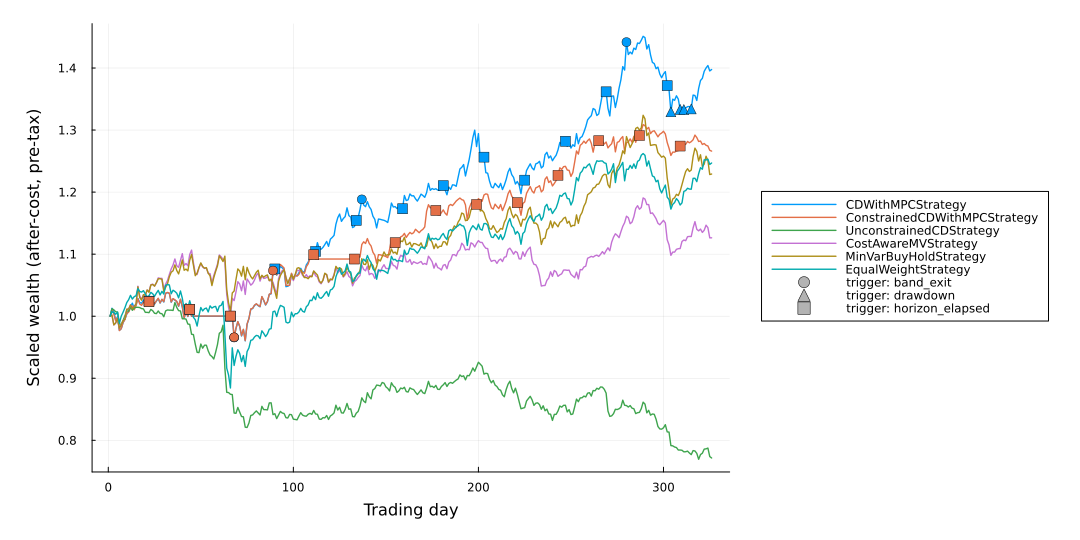

In [5]:
p = let
    plt = plot(legend = :outerright, size = (1080, 540),
               xlabel = "Trading day",
               ylabel = "Scaled wealth (after-cost, pre-tax)",
               left_margin   = 10Plots.mm,
               bottom_margin =  8Plots.mm,
               right_margin  =  6Plots.mm,
               top_margin    =  4Plots.mm)

    # Wealth curves (scaled so each strategy starts at 1.0) + capture each line's color
    line_color = Dict{String, Any}()
    for (name, r) in canonical
        w = r.wealth_after_cost_pretax
        plot!(plt, w ./ w[1]; label = name, lw = 1.4)
        line_color[name] = plt.series_list[end][:linecolor]
    end

    # Trigger-event overlay (uses global day index t_global from MyMPCTrigger).
    # Shape encodes reason; color matches the strategy's line.
    reason_shape = (band_exit = :circle, drawdown = :utriangle, horizon_elapsed = :rect)
    for (name, r) in canonical
        isempty(r.trigger_log) && continue
        w  = r.wealth_after_cost_pretax
        w0 = w[1]
        for (reason, shape) in pairs(reason_shape)
            evts = filter(t -> t.fired && t.reason === reason, r.trigger_log)
            isempty(evts) && continue
            ts = [t.t_global for t in evts]
            ys = [w[t.t_global] / w0 for t in evts]
            scatter!(plt, ts, ys;
                     label = "", markershape = shape, markersize = 5,
                     markercolor = line_color[name],
                     markerstrokewidth = 0.4, markerstrokecolor = :black)
        end
    end

    # Legend stubs for trigger reasons (neutral color, drawn off-canvas)
    for (reason, shape) in pairs(reason_shape)
        scatter!(plt, [NaN], [NaN];
                 label = "trigger: " * String(reason),
                 markershape = shape, markersize = 5,
                 markercolor = :gray70, markerstrokecolor = :black,
                 markerstrokewidth = 0.4)
    end
    plt
end


### MPC Trigger Reasons

Only the two MPC strategies (CDWithMPC, ConstrainedCDWithMPC) maintain a trigger log. Each fire is tagged with the condition that tripped it (out-of-band, $T$-day refresh, or the drawdown circuit-breaker), so we can see whether re-allocations are driven by realized drift or by the calendar. Counts shown are for the canonical reporting seed.


In [6]:
let
    for (name, r) in canonical
        if !isempty(r.trigger_log)
            reasons = [t.reason for t in r.trigger_log if t.fired]
            if !isempty(reasons)
                counts = Dict(rs => count(==(rs), reasons) for rs in unique(reasons))
                println(rpad(name, 35), "  ", counts)
            end
        end
    end
end;


CDWithMPCStrategy                    Dict(:drawdown => 4, :horizon_elapsed => 13, :band_exit => 3)
ConstrainedCDWithMPCStrategy         Dict(:horizon_elapsed => 13, :band_exit => 2)


### Multi-Seed Backtest Distribution

The two MPC strategies depend on `BACKTEST_RNG_SEED` through their `forward_project` Monte Carlo paths. To honestly report performance we run each strategy across 20 seeds (`2001:2020`) and report the distribution of outcomes. The four non-MPC strategies (EW, MinVar, UnconstrainedCD, CostAwareMV) are deterministic given prices and collapse to a single value; they are included in the table to keep the row set uniform.


In [7]:
let
    rows = NamedTuple[]
    for (name, agg) in bt_mc["summary"]
        sh = agg["sharpe_mc"]
        dd = agg["max_dd_mc"]
        wt = agg["W_T_over_W0_mc"]
        push!(rows, (Strategy = name,
            Sharpe_min    = round(minimum(sh); digits = 3),
            Sharpe_med    = round(median(sh);  digits = 3),
            Sharpe_max    = round(maximum(sh); digits = 3),
            MaxDD_med_pct = round(median(dd) * 100; digits = 1),
            WT_W0_med     = round(median(wt); digits = 3),
            nTrig_med     = round(Int, median(agg["n_mpc_triggers_mc"]))))
    end
    sort!(rows; by = r -> -r.Sharpe_med)
    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ------------------------------ ------------ ------------ ------------ --------------- ----------- -----------
                      Strategy   Sharpe_min   Sharpe_med   Sharpe_max   MaxDD_med_pct   WT_W0_med   nTrig_med 
                        String      Float64      Float64      Float64         Float64     Float64       Int64 
 ------------------------------ ------------ ------------ ------------ --------------- ----------- -----------
             CDWithMPCStrategy        1.358        2.079        2.079             8.4       1.398          20
  ConstrainedCDWithMPCStrategy        1.542        1.681        2.166             7.5       1.266          16
         MinVarBuyHoldStrategy        1.199        1.199        1.199            11.0       1.229           0
           EqualWeightStrategy         1.16         1.16         1.16            15.9       1.247           0
           CostAwareMVStrategy        0.732        0.732        0.732             9.7       1.126           0
      

#### Sharpe distribution histogram for ConstrainedCDWithMPCStrategy

Hold-out Sharpe distribution for the constrained-CD + MPC design across the 20 backtest seeds. The four deterministic strategies (EW, MinVar, UnconstrainedCD, CostAwareMV) collapse to a single point; they do not vary with the RNG.


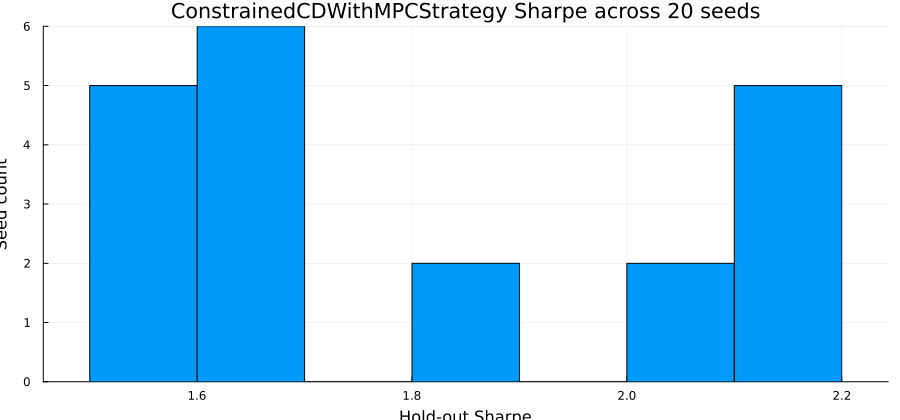

In [8]:
let
    sh = bt_mc["summary"]["ConstrainedCDWithMPCStrategy"]["sharpe_mc"]
    histogram(sh; bins = 10, xlabel = "Hold-out Sharpe", ylabel = "Seed count",
        title = "ConstrainedCDWithMPCStrategy Sharpe across $n_seeds seeds",
        legend = false, size = (900, 420))
end


### σ_max Sensitivity Sweep

How sensitive is `ConstrainedCDWithMPC` to the covariance budget $\sigma_{\max}$? `scripts/07_sigma_max_sweep.jl` answers it directly: we re-run the 20-seed MC hold-out at $\sigma_{\max} \in \{1.5, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 10.0\}$ (growth-rate-vol units; recall $\sigma_m \approx 2.7$). Everything else is held at the 06 defaults: same frozen 33-ticker basket, same hold-out window, same MPC spec ($T = 21$, $z = 1.96$, $D_{\max} = 0.08$, $N = 1000$ paths), same $K_{\text{turnover}} = 0.10 \cdot B_0 = \$10{,}000$, same $w_{\max} = 0.20$, same cost and tax models, same seed range $\{2001, \ldots, 2020\}$. Only `σ_max` on `ConstrainedCDWithMPCStrategy` is varied. The other five strategies are $\sigma_{\max}$-invariant; we reference `CDWithMPC`'s 2.079 median Sharpe from the 06 run as the no-constraint upper bound.

The cell below loads `scripts/data/sigma_max_sweep.jld2`, binds the result to the global `sweep::Dict{String,Any}`, and prints the per-$\sigma_{\max}$ summary table.


In [9]:
let
    global sweep
    _check_artifact(joinpath(_PATH_TO_ARTIFACTS, "sigma_max_sweep.jld2"))
    sweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "sigma_max_sweep.jld2"))
    grid = sweep["sigma_max_grid"]
    rows = NamedTuple[]
    for σmax in grid
        s   = sweep["summary"][σmax]
        sh  = s["sharpe_mc"]
        dd  = s["max_dd_mc"]
        tn  = s["ann_turnover_mc"]
        rps = s["trigger_reason_per_seed"]
        push!(rows, (σ_max     = σmax,
                     Shp_Q25   = round(quantile(sh, 0.25); digits = 3),
                     Shp_med   = round(median(sh);        digits = 3),
                     Shp_Q75   = round(quantile(sh, 0.75); digits = 3),
                     MaxDD_pct = round(median(dd) * 100;  digits = 1),
                     Turn_med  = round(median(tn);         digits = 2),
                     band      = round(get(rps, "band_exit",       0.0); digits = 1),
                     dd_trig   = round(get(rps, "drawdown",        0.0); digits = 1),
                     horizon   = round(get(rps, "horizon_elapsed", 0.0); digits = 1)))
    end
    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
    σ_max   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon 
  Float64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64 
 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
      1.5     1.848     1.977      1.99         5.3       9.98       4.4       0.0      13.0
      2.0     1.742     1.874     1.909         5.9      12.18       4.2       0.0      13.0
     2.25     1.682     1.814     1.914         6.7      12.87       4.0       0.0      13.0
      2.5     1.679     1.902     2.004         7.5      13.19       3.8       0.0      13.0
     2.75     1.659      1.92     2.006         7.5      13.32       3.8       0.0      13.0
      3.0     1.657     1.927     2.005         7.5      13.34       3.8       0.0      13.0
      3.5     1.657     1.927     2.005         7.5      13.34    

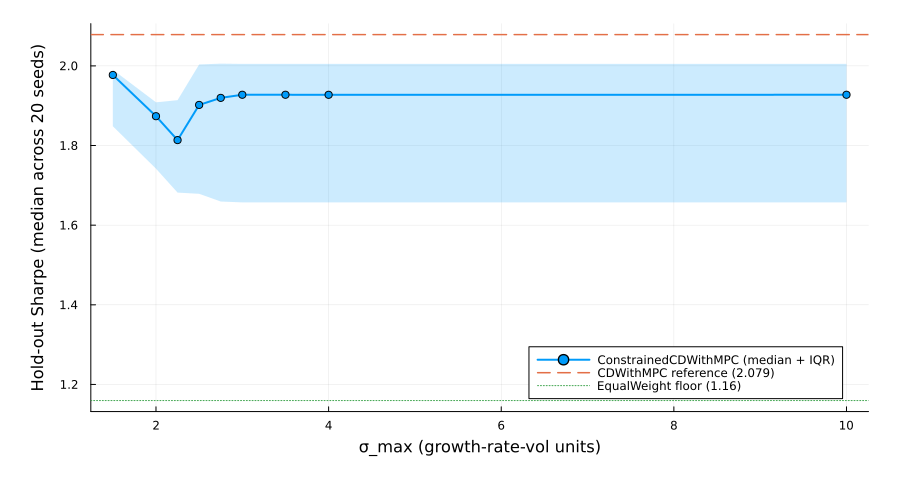

In [10]:
p_sigma = let
    grid = sweep["sigma_max_grid"]
    shp_med = [median(sweep["summary"][σ]["sharpe_mc"])           for σ in grid]
    shp_q25 = [quantile(sweep["summary"][σ]["sharpe_mc"], 0.25)   for σ in grid]
    shp_q75 = [quantile(sweep["summary"][σ]["sharpe_mc"], 0.75)   for σ in grid]

    # Reference Sharpes from the 06 bake-off (σ_max-invariant strategies)
    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])

    plt = plot(size = (900, 480), legend = :bottomright,
               xlabel = "σ_max (growth-rate-vol units)",
               ylabel = "Hold-out Sharpe (median across 20 seeds)",
               left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
               right_margin = 6Plots.mm, top_margin = 4Plots.mm)
    plot!(plt, grid, shp_med;
          ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
          fillalpha = 0.20, lw = 2, marker = :circle,
          label = "ConstrainedCDWithMPC (median + IQR)")
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
           label = "CDWithMPC reference (" * string(round(cd_mpc_med; digits = 3)) * ")")
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
           label = "EqualWeight floor (" * string(round(ew_med; digits = 3)) * ")")
    plt
end


### w_max Sensitivity Sweep

`scripts/08_w_max_sweep.jl` varies the per-name concentration cap $w_{\max}$ while pinning $\sigma_{\max} = 10.0$ (cov constraint inactive) and $K_{\text{turnover}} = 0.10 \cdot B_0 = \$10{,}000$ (06 default). The grid is $w_{\max} \in \{0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.70, 1.0\}$. At $w_{\max} = 1.0$ all three client-facing constraints are effectively off, so `ConstrainedCDWithMPC` should asymptote to `CDWithMPC`'s closed-form behavior; this is the sanity-check end of the grid.

The cell below loads `scripts/data/w_max_sweep.jld2`, binds the result to `wsweep::Dict{String,Any}`, and prints the per-$w_{\max}$ summary table.


In [11]:
let
    global wsweep
    _check_artifact(joinpath(_PATH_TO_ARTIFACTS, "w_max_sweep.jld2"))
    wsweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "w_max_sweep.jld2"))
    grid = wsweep["w_max_grid"]
    rows = NamedTuple[]
    for wmax in grid
        s   = wsweep["summary"][wmax]
        sh  = s["sharpe_mc"]
        dd  = s["max_dd_mc"]
        tn  = s["ann_turnover_mc"]
        rps = s["trigger_reason_per_seed"]
        push!(rows, (w_max     = wmax,
                     Shp_Q25   = round(quantile(sh, 0.25); digits = 3),
                     Shp_med   = round(median(sh);        digits = 3),
                     Shp_Q75   = round(quantile(sh, 0.75); digits = 3),
                     MaxDD_pct = round(median(dd) * 100;  digits = 1),
                     Turn_med  = round(median(tn);        digits = 2),
                     band      = round(get(rps, "band_exit",       0.0); digits = 1),
                     dd_trig   = round(get(rps, "drawdown",        0.0); digits = 1),
                     horizon   = round(get(rps, "horizon_elapsed", 0.0); digits = 1)))
    end
    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
    w_max   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon 
  Float64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64 
 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
      0.1     1.059     1.432     1.733         7.5      12.07       3.8       0.0      13.6
     0.15     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
      0.2     1.657     1.927     2.005         7.5      13.34       3.8       0.0      13.0
      0.3     1.528     1.548     1.656         8.1      14.08       3.2       1.6      12.7
      0.4     1.434     1.434     1.434         9.8      24.04       2.8      12.8      12.2
      0.5     0.698     0.852     1.474        13.7      26.56       3.4      20.6      11.1
      0.7     2.079     2.079     2.079         8.4      19.06    

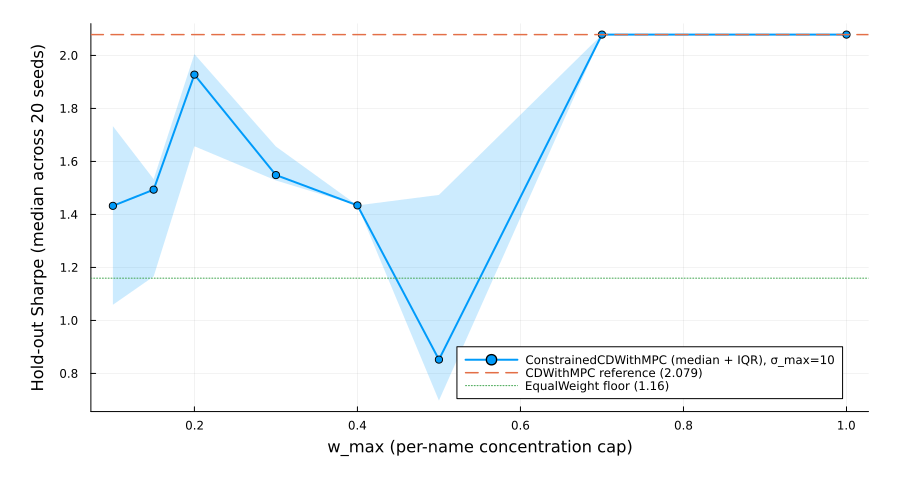

In [12]:
p_wmax = let
    grid = wsweep["w_max_grid"]
    shp_med = [median(wsweep["summary"][w]["sharpe_mc"])           for w in grid]
    shp_q25 = [quantile(wsweep["summary"][w]["sharpe_mc"], 0.25)   for w in grid]
    shp_q75 = [quantile(wsweep["summary"][w]["sharpe_mc"], 0.75)   for w in grid]

    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])

    plt = plot(size = (900, 480), legend = :bottomright,
               xlabel = "w_max (per-name concentration cap)",
               ylabel = "Hold-out Sharpe (median across 20 seeds)",
               left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
               right_margin = 6Plots.mm, top_margin = 4Plots.mm)
    plot!(plt, grid, shp_med;
          ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
          fillalpha = 0.20, lw = 2, marker = :circle,
          label = "ConstrainedCDWithMPC (median + IQR), σ_max=10")
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
           label = "CDWithMPC reference (" * string(round(cd_mpc_med; digits = 3)) * ")")
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
           label = "EqualWeight floor (" * string(round(ew_med; digits = 3)) * ")")
    plt
end


### K_turnover Sensitivity Sweep

`scripts/09_k_turnover_sweep.jl` is the third and last single-variable sweep on the three client-facing constraints. We pin $\sigma_{\max} = 10.0$ (cov constraint inactive) and $w_{\max} = 0.15$, and vary the per-decision turnover budget across $K_{\text{turnover}} / B_0 \in \{0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0, 10.0\}$, i.e., from \$1{,}000 to \$1{,}000{,}000 with the default \$10{,}000 (the $0.10 \cdot B_0$ baseline used in 06) at the middle of the grid. The constraint enforced inside the optimization is $\bar{c}\,\|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}$ with $\bar{c} = \$0.05$ per share, so $K_{\text{turnover}} = \$1{,}000$ already permits 20,000 shares of net trading per decision, a generous budget for a \$100{,}000 portfolio.

In an earlier run the slack-variable encoding of this L1 constraint had a degeneracy bug that pulled the solver to a suboptimum; the current `Allocator.jl` skips the slack encoding when the constraint is provably inactive (`c̄ · max ‖n − n_prev‖_1 ≤ K_turnover`), eliminating the degenerate directions. After that fix, the sweep is expected to be **flat** across the grid for this basket and budget, since the constraint never binds at any realistic per-decision turnover value.

The cell below loads `scripts/data/k_turnover_sweep.jld2`, binds the result to `ksweep::Dict{String,Any}`, and prints the per-$K_{\text{turnover}}$ summary table.


In [ ]:
let
    global ksweep # really bad idea to reuse this var name, but it's late and I want to get the report out
    _check_artifact(joinpath(_PATH_TO_ARTIFACTS, "k_turnover_sweep.jld2"))
    ksweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "k_turnover_sweep.jld2"))
    grid = ksweep["k_turnover_grid"]
    B0 = ksweep["config"]["B_0"]
    rows = NamedTuple[]
    for kt in grid
        s   = ksweep["summary"][kt]
        sh  = s["sharpe_mc"]
        dd  = s["max_dd_mc"]
        tn  = s["ann_turnover_mc"]
        rps = s["trigger_reason_per_seed"]
        push!(rows, (K_turnover = round(Int, kt),
                     x_B0       = round(kt / B0; digits = 2),
                     Shp_Q25    = round(quantile(sh, 0.25); digits = 3),
                     Shp_med    = round(median(sh);        digits = 3),
                     Shp_Q75    = round(quantile(sh, 0.75); digits = 3),
                     MaxDD_pct  = round(median(dd) * 100;  digits = 1),
                     Turn_med   = round(median(tn);        digits = 2),
                     band       = round(get(rps, "band_exit",       0.0); digits = 1),
                     dd_trig    = round(get(rps, "drawdown",        0.0); digits = 1),
                     horizon    = round(get(rps, "horizon_elapsed", 0.0); digits = 1)))
    end
    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ------------ --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
  K_turnover      x_B0   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon 
       Int64   Float64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64 
 ------------ --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
        1000      0.01     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
        2000      0.02     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
        5000      0.05     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
       10000       0.1     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
       20000       0.2     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
       50000       0.5     1.166     1.493

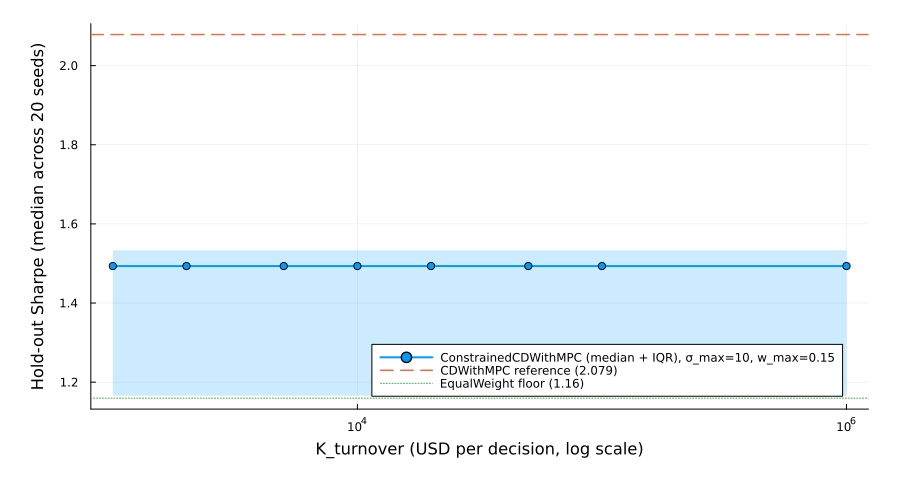

In [14]:
p_kturn = let
    grid = ksweep["k_turnover_grid"]
    shp_med = [median(ksweep["summary"][k]["sharpe_mc"])           for k in grid]
    shp_q25 = [quantile(ksweep["summary"][k]["sharpe_mc"], 0.25)   for k in grid]
    shp_q75 = [quantile(ksweep["summary"][k]["sharpe_mc"], 0.75)   for k in grid]

    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])

    plt = plot(size = (900, 480), legend = :bottomright,
               xscale = :log10,
               xlabel = "K_turnover (USD per decision, log scale)",
               ylabel = "Hold-out Sharpe (median across 20 seeds)",
               left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
               right_margin = 6Plots.mm, top_margin = 4Plots.mm)
    plot!(plt, grid, shp_med;
          ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
          fillalpha = 0.20, lw = 2, marker = :circle,
          label = "ConstrainedCDWithMPC (median + IQR), σ_max=10, w_max=0.15")
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
           label = "CDWithMPC reference (" * string(round(cd_mpc_med; digits = 3)) * ")")
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
           label = "EqualWeight floor (" * string(round(ew_med; digits = 3)) * ")")
    plt
end


___
## Summary

The MPC trigger discipline and the constraint layer **both add value** on the 2025-2026 hold-out, and they do so along complementary axes. `CDWithMPCStrategy` (unconstrained Cobb-Douglas allocator fired only on MPC trigger) delivers a hold-out Sharpe of **2.079** and max-drawdown of **8.4%**, the top scorer in the bake-off. The same unconstrained allocator at *daily cadence* (the live engine's failure mode reproduced in backtest) collapses to Sharpe **-1.263** and max-drawdown **24.7%**, with annualized turnover of about 241× the portfolio. Adding the covariance, turnover, and concentration constraints on top of the MPC trigger gives `ConstrainedCDWithMPCStrategy`, which posts Sharpe **1.681** and max-drawdown **7.5%**: roughly 0.4 Sharpe below `CDWithMPC` in exchange for about one percentage point of additional drawdown protection, a clean risk-return tradeoff that holds up to client interpretation.

> **Key Takeaways:**
> 
> * **Cadence is the load-bearing fix:** Moving from daily rebalance to MPC-triggered rebalance turns the unconstrained Cobb-Douglas strategy from worst to best in the bake-off, a Sharpe swing of more than three full units. The trigger discipline (forward-project, refresh on band exit, calendar elapse, or drawdown breach) is what fixes the live engine's flat-with-bleed failure mode; every other design choice is layered on top.
> 
> * **The constraint layer trades Sharpe for drawdown control:** Adding covariance, turnover, and concentration constraints costs about 0.4 hold-out Sharpe relative to `CDWithMPC`, but buys roughly one percentage point of max-drawdown reduction (7.5% versus 8.4%) and a far steadier trigger profile (zero drawdown-circuit-breaker fires in the post-fix run versus several for the unconstrained-MPC variant). The constraint-versus-no-constraint choice is not a free lunch, but it is not net-negative either.
> 
> * **Read distributions, not single trials:** The two MPC strategies are stochastic in their forward-projection Monte Carlo paths, so the 20-seed median is the honest summary statistic and any single seed misrepresents the strategy. The four deterministic baselines collapse to a single point per metric, which is directly comparable to the MC median rather than to any individual seed.

This closes the loop opened by the live-engine post-mortem in `constrained_cobb_douglas.md`. The original engine had no notion of cost, no notion of risk, no notion of holding, and fired on a clock with no information content. The MPC discipline fixes the cadence problem on its own; the constraint layer adds a tunable risk-control overlay on top, with the covariance budget $\sigma_{\max}$ as the dominant lever (tight values around 1.5 actually *improve* both Sharpe and drawdown in the σ_max sweep), the concentration cap $w_{\max}$ as a secondary lever with a sharp non-monotonic profile, and the per-decision turnover budget $K_{\text{turnover}}$ inactive at any reasonable value for this basket size.

**Two engineering fixes shaped the current numbers and are worth flagging for any reader auditing prior versions of this notebook.** First, the L1 turnover slack encoding in `solve_constrained_cd` had a degenerate-direction bug that left ~55% of the budget unspent on every fire in synthetic stress tests; the fix detects when `c̄ · max ‖n − n_prev‖_1 ≤ K_turnover` and skips the slack variables entirely. Second, `allocate(::ConstrainedCDWithMPCStrategy)` previously held existing positions on the `:no_preferred` regime signal, while `CDWithMPCStrategy`'s closed form effectively sold to cash on the same signal; the two are now unified so the bake-off compares the strategies on the constraint effect alone, not on a free defensive option for the closed form.

### Disclaimer

This content is for educational purposes only and does not constitute investment advice. The examples use real historical data, a frozen SIM calibration on 2014-2024, and a single 2025-2026 forward window; conclusions about cost-aware constrained allocation and MPC trigger discipline do not generalize to other markets, time periods, or client risk profiles without re-calibration.

___
